# Example 7: Agent-Assisted LAS Packet Walkthrough

This notebook is the detailed end-user recipe for building an open-hole
packet one step at a time through the public `wellplot.agent` API.

Unlike the YAML-first user notebooks, this one is credentialed and manual:

- it uses a live hosted model through `wellplot.agent`
- it runs the local `wellplot-mcp` server under the hood
- it starts from a tiny starter logfile and revises the same draft in steps
- it shows a preview image after each major authoring cell

What you will do:

1. point the draft at your own LAS file
2. generate the first-page header and add remarks
3. add one track at a time
4. preview the evolving section after each step
5. render the final PDF through the public agent session helper

Prerequisites:

- `python -m pip install "wellplot[agent,las,notebook]"`
- one supported OpenAI credential source under the repository or job root:
  `OPENAI_API_KEY`, `.env.local`, `.env`, `OPENAI_API_KEY.txt`, or
  `openai_api_key.txt`
- run the notebook from a checkout of this repository so the example data and
  workspace folders are available

This notebook is intentionally unexecuted in git because it depends on a live
model, local credentials, and your chosen LAS file.


In [8]:
import sys
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active "
        "environment before running this notebook."
    ) from exc

# Walk upward from the current working directory until we find the
# repository checkout that holds the example sources and sample data.
cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository "
        "so the example files and sample data are available."
    )

EXAMPLES_DIR = REPO_ROOT / "examples"
WORKSPACE_DIR = REPO_ROOT / "workspace"
WORKSPACE_RENDERS = WORKSPACE_DIR / "renders"
WORKSPACE_RENDERS.mkdir(parents=True, exist_ok=True)

examples_path = str(EXAMPLES_DIR)
if examples_path not in sys.path:
    sys.path.insert(0, examples_path)

print("wellplot version:", wellplot.__version__)
print("Examples root:", EXAMPLES_DIR)
print("Render output:", WORKSPACE_RENDERS)

wellplot version: 0.3.0
Examples root: /home/user/projects/well_log_os/examples
Render output: /home/user/projects/well_log_os/workspace/renders


In [9]:
import shutil
from pathlib import Path
from textwrap import dedent

from IPython.display import Code, Image, display
from wellplot.agent import AuthoringSession

MODEL = os.getenv("OPENAI_MODEL", "gpt-5.4")
SEED_MAX_ROUNDS = 12
REVISION_MAX_ROUNDS = 18
TUTORIAL_DIR = REPO_ROOT / "workspace" / "tutorials" / "agent_las_step_by_step"
TUTORIAL_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_LAS_PATH = REPO_ROOT / "workspace" / "data" / "30-23a-3 8117_d.las"
USER_LAS_PATH = TUTORIAL_DIR / "user_input.las"
STARTER_LOGFILE = TUTORIAL_DIR / "agent_starter.log.yaml"
DRAFT_LOGFILE = TUTORIAL_DIR / "agent_open_hole_draft.log.yaml"
FINAL_PDF = TUTORIAL_DIR / "agent_open_hole_draft.pdf"

if not USER_LAS_PATH.exists():
    shutil.copyfile(SAMPLE_LAS_PATH, USER_LAS_PATH)


def repo_relative(path: str | Path) -> str:
    raw = Path(path)
    absolute = raw if raw.is_absolute() else (REPO_ROOT / raw)
    return absolute.resolve().relative_to(REPO_ROOT).as_posix()


def show_agent_result(title: str, result, *, preview: str = "section") -> None:
    print(title)
    print("Draft:", result.draft_logfile)
    print("Tool trace:", [item.name for item in result.tool_trace])
    for line in result.change_summary.get("summary_lines", []):
        print(" -", line)
    image_bytes = result.report_preview_png if preview == "report" else result.section_preview_png
    display(Image(data=image_bytes))


session = AuthoringSession.from_local_mcp(
    provider="openai",
    model=MODEL,
    server_root=REPO_ROOT,
)

print("Model:", MODEL)
print("Tutorial folder:", repo_relative(TUTORIAL_DIR))
print("User LAS path:", repo_relative(USER_LAS_PATH))
print("Draft logfile:", repo_relative(DRAFT_LOGFILE))
print("Final PDF:", repo_relative(FINAL_PDF))

Model: gpt-5.4
Tutorial folder: workspace/tutorials/agent_las_step_by_step
User LAS path: workspace/tutorials/agent_las_step_by_step/user_input.las
Draft logfile: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Final PDF: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.pdf


## 1. Write A Minimal Starter Logfile

This starter keeps one compact overview track, one reference depth track, and a source-key-backed heading. The first agent pass will switch the section over to your own LAS file and keep the draft intentionally sparse.


In [10]:
starter_source = Path(os.path.relpath(SAMPLE_LAS_PATH, start=TUTORIAL_DIR)).as_posix()
starter_yaml = (
    dedent(
        f"""
    version: 1
    name: Agent LAS Starter
    render:
      backend: matplotlib
      output_path: ./agent_open_hole_draft.pdf
      dpi: 144
    document:
      page:
        size: A4
        orientation: portrait
        continuous: false
        bottom_track_header_enabled: true
        track_gap_mm: 0
        track_header_height_mm: 24
      depth:
        unit: ft
        scale: 240
      layout:
        heading:
          enabled: true
          provider_name: Company
          general_fields:
            - key: company
              label: Company
              source_key: COMP
            - key: well
              label: Well
              source_key: WELL
            - key: field
              label: Field
              source_key: FLD
            - key: service_company
              label: Service Company
              source_key: SRVC
          service_titles:
            - value: Open Hole Quicklook
              alignment: center
              bold: true
          detail:
            kind: open_hole
            title: Open Hole Metadata
            rows:
              - label: Date
                values:
                  - source_key: DATE
                  - ""
              - label_cells:
                  - UWI
                  - Province
                columns:
                  - cells:
                      - source_key: UWI
                  - cells:
                      - source_key: PROV
        log_sections:
          - id: main
            title: Main Review
            subtitle: Placeholder starter source
            depth_range:
              - 8400
              - 9300
            data:
              source_path: {starter_source}
              source_format: las
            tracks:
              - id: gr_sp
                title: GR/SP
                kind: normal
                width_mm: 32
                position: 1
              - id: depth
                title: Depth
                kind: reference
                width_mm: 18
                position: 2
                reference:
                  axis: depth
                  define_layout: true
                  unit: ft
                  scale_ratio: 240
                  major_step: 100
                  secondary_grid:
                    display: true
                    line_count: 4
      bindings:
        on_missing: skip
        channels:
          - channel: GR
            track_id: gr_sp
            kind: curve
            label: GR
            style:
              color: "#2e7d32"
    """
    ).strip()
    + "\n"
)

STARTER_LOGFILE.write_text(starter_yaml, encoding="utf-8")
display(Code(starter_yaml, language="yaml"))

version: 1
name: Agent LAS Starter
render:
  backend: matplotlib
  output_path: ./agent_open_hole_draft.pdf
  dpi: 144
document:
  page:
    size: A4
    orientation: portrait
    continuous: false
    bottom_track_header_enabled: true
    track_gap_mm: 0
    track_header_height_mm: 24
  depth:
    unit: ft
    scale: 240
  layout:
    heading:
      enabled: true
      provider_name: Company
      general_fields:
        - key: company
          label: Company
          source_key: COMP
        - key: well
          label: Well
          source_key: WELL
        - key: field
          label: Field
          source_key: FLD
        - key: service_company
          label: Service Company
          source_key: SRVC
      service_titles:
        - value: Open Hole Quicklook
          alignment: center
          bold: true
      detail:
        kind: open_hole
        title: Open Hole Metadata
        rows:
          - label: Date
            values:
              - source_key: DATE
              - ""
          - label_cells:
              - UWI
              - Province
            columns:
              - cells:
                  - source_key: UWI
              - cells:
                  - source_key: PROV
    log_sections:
      - id: main
        title: Main Review
        subtitle: Placeholder starter source
        depth_range:
          - 8400
          - 9300
        data:
          source_path: ../../data/30-23a-3 8117_d.las
          source_format: las
        tracks:
          - id: gr_sp
            title: GR/SP
            kind: normal
            width_mm: 32
            position: 1
          - id: depth
            title: Depth
            kind: reference
            width_mm: 18
            position: 2
            reference:
              axis: depth
              define_layout: true
              unit: ft
              scale_ratio: 240
              major_step: 100
              secondary_grid:
                display: true
                line_count: 4
  bindings:
    on_missing: skip
    channels:
      - channel: GR
        track_id: gr_sp
        kind: curve
        label: GR
        style:
          color: "#2e7d32"

## 2. Create The Initial Draft

The first natural-language request clones the starter, changes the section data source to `USER_LAS_PATH`, updates the subtitle, and keeps only the seeded overview track plus the depth track while the packet is still sparse.


Initial draft
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'inspect_authoring_vocab', 'inspect_data_source', 'set_section_data_source', 'set_heading_content', 'set_heading_content', 'set_remarks_content', 'summarize_logfile_draft']
 - Heading content changed.


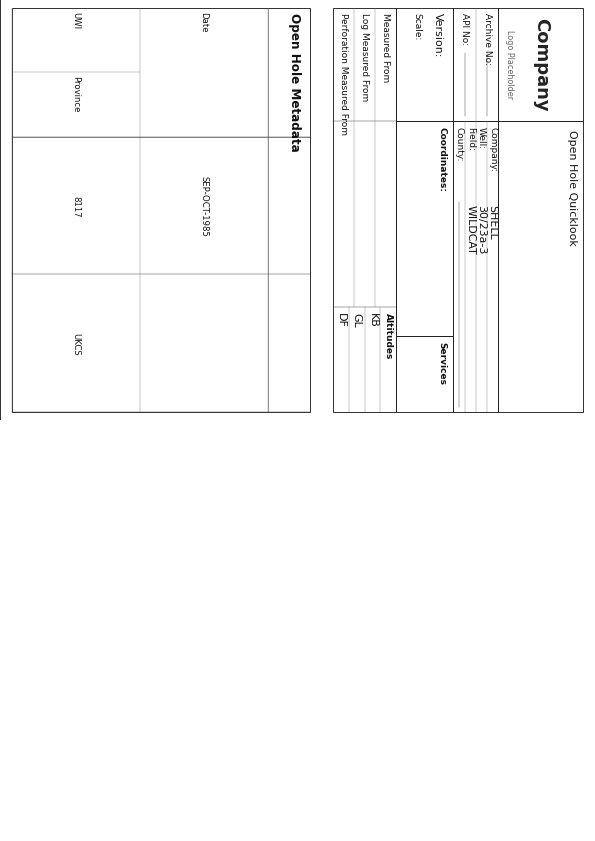

In [11]:
seed_result = await session.run(
    goal=dedent(
        f"""
        Start from the existing starter logfile and create the initial open-hole draft.

        - Change the only section data source to `{repo_relative(USER_LAS_PATH)}`.
        - Keep the section id `main`.
        - Set the section subtitle to the LAS filename.
        - Keep the seeded `gr_sp` overview track before the depth track.
        - Do not add any additional tracks yet.
        - Keep the source-key-backed heading fields.
        - Set the first service title to `Open Hole Quicklook`.
        - Do not add remarks yet.
        """
    ).strip(),
    source_logfile_path=repo_relative(STARTER_LOGFILE),
    output_logfile=repo_relative(DRAFT_LOGFILE),
    max_rounds=SEED_MAX_ROUNDS,
)

show_agent_result("Initial draft", seed_result, preview="report")

## 3. Add The Remarks Block

Revise the same draft with one short remarks block that explains what the packet is for and keeps the public-data framing concise.


Remarks added
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'inspect_authoring_vocab', 'set_remarks_content', 'set_remarks_content', 'set_remarks_content']
 - Remarks content changed.


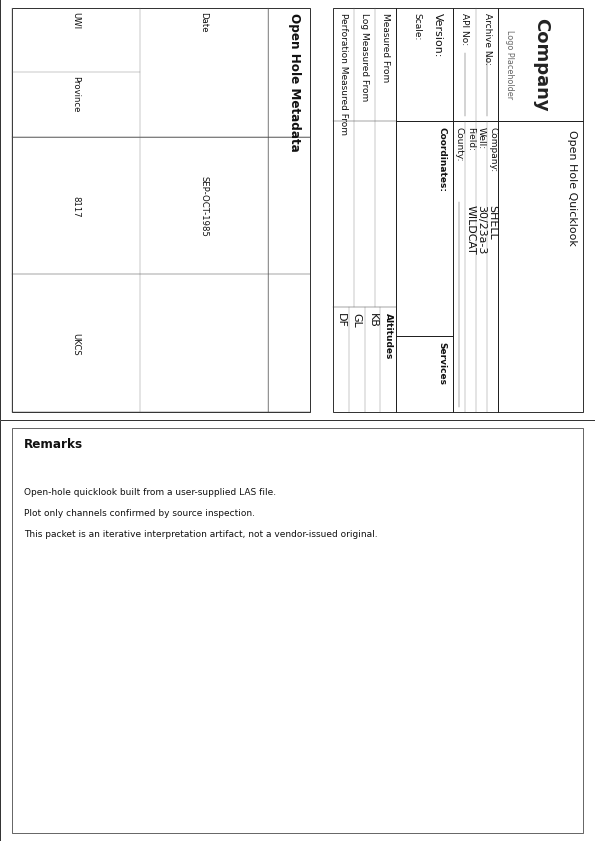

In [12]:
remarks_result = await session.revise(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    feedback=dedent(
        """
        Add one concise remarks block to the first page.

        - Keep it short and readable.
        - Mention that this is an open-hole quicklook built from a user-supplied LAS file.
        - Mention that only channels confirmed through the source inspection should be plotted.
        - Mention that this packet is an iterative interpretation artifact, not a vendor-issued original.
        """
    ).strip(),
    max_rounds=REVISION_MAX_ROUNDS,
)

show_agent_result("Remarks added", remarks_result, preview="report")

## 4. Refine The GR/SP Overview Track

Ask the model to refine the seeded overview track and to bind curves only when they actually exist in the LAS file.


GR/SP overview track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'bind_curve', 'bind_curve', 'update_curve_binding', 'summarize_logfile_draft', 'bind_curve']
 - Added curve bindings: main/gr_sp/SP.


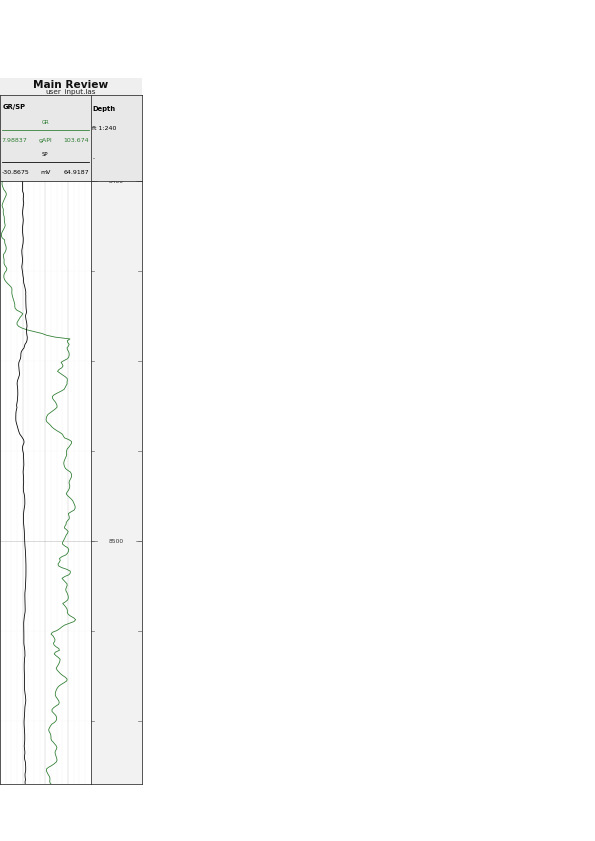

In [13]:
gr_sp_result = await session.revise(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    feedback=dedent(
        """
        Revise the existing draft.

        - Revise the existing `gr_sp` overview track before the depth track.
        - If both GR and SP are available, bind both to this track.
        - If SP is missing, keep a GR-only overview.
        - Use a readable green gamma-ray curve and conventional linear scaling.
        """
    ).strip(),
    max_rounds=REVISION_MAX_ROUNDS,
)

show_agent_result("GR/SP overview track", gr_sp_result)

## 5. Add The Resistivity Track

The next revision adds one log-scale resistivity track and prefers the deepest curve visually if several resistivity channels are available.


Resistivity track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'add_track', 'move_track', 'bind_curve', 'bind_curve', 'bind_curve', 'inspect_authoring_vocab', 'bind_curve', 'bind_curve', 'bind_curve']
 - Section main: added tracks ['resistivity'].
 - Added curve bindings: main/resistivity/ILD, main/resistivity/ILM, main/resistivity/MSFL.


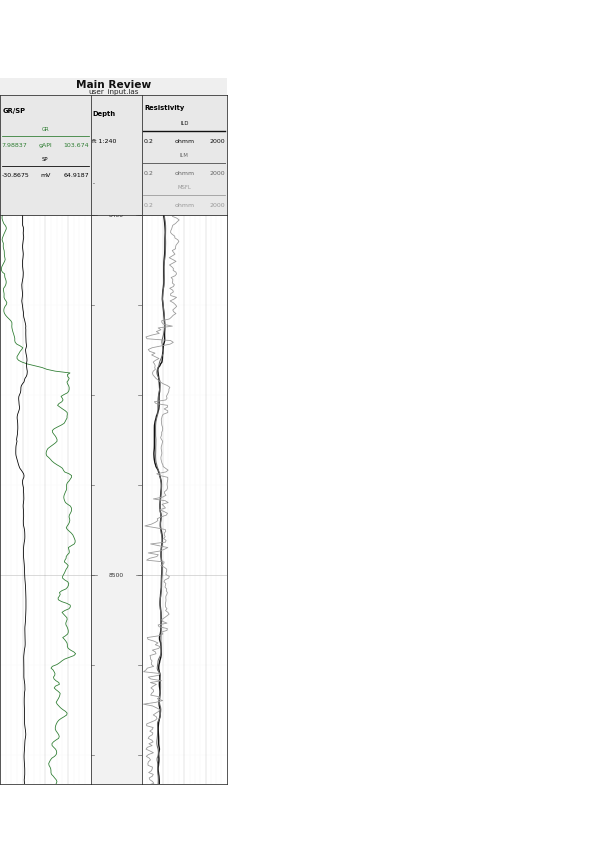

In [14]:
resistivity_result = await session.revise(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    feedback=dedent(
        """
        Revise the existing draft.

        - Add one resistivity track after the depth track.
        - Use a logarithmic scale from 0.2 to 2000 ohm.m.
        - Bind the deep, medium, and shallow resistivity curves that are available.
        - Keep the deepest resistivity curve visually strongest.
        """
    ).strip(),
    max_rounds=REVISION_MAX_ROUNDS,
)

show_agent_result("Resistivity track", resistivity_result)

## 6. Add The Porosity Overlay Track

Now add the density-neutron overlay and ask the model to create a crossover fill only when both channels are available.


Porosity overlay track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'inspect_authoring_vocab', 'add_track', 'move_track', 'bind_curve', 'bind_curve', 'bind_curve', 'bind_curve']
 - Section main: added tracks ['porosity'].
 - Added curve bindings: main/porosity/NPHI, main/porosity/RHOB.


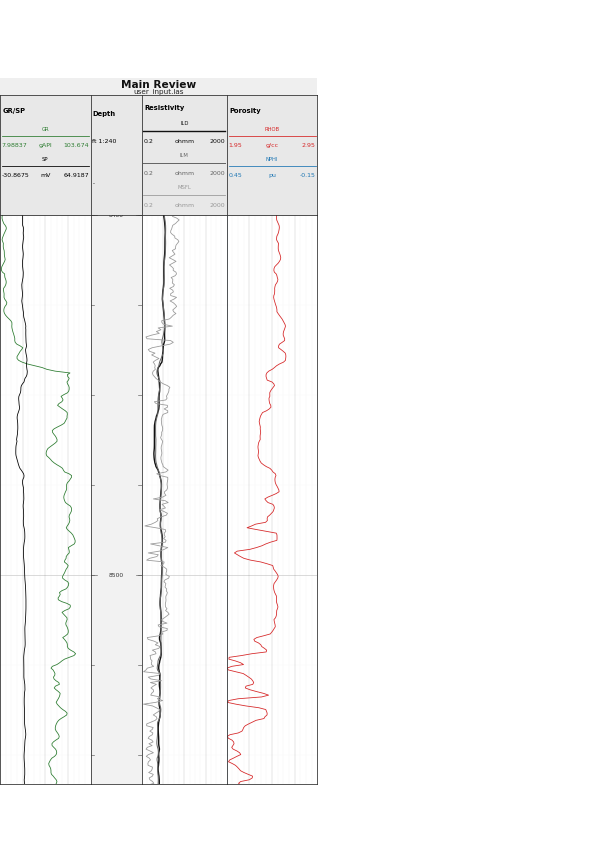

In [15]:
porosity_result = await session.revise(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    feedback=dedent(
        """
        Revise the existing draft.

        - Add one porosity track after the resistivity track.
        - If RHOB and NPHI are available, overlay them in the same track.
        - Reverse the neutron scale so crossover reads naturally.
        - Add a crossover fill only when both RHOB and NPHI are present.
        """
    ).strip(),
    max_rounds=REVISION_MAX_ROUNDS,
)

show_agent_result("Porosity overlay track", porosity_result)

## 7. Add A Narrow QC Track

Finish the log section by adding a small QC track for supporting curves such as caliper, PEF, or DRHO when the source contains them.


QC track
Draft: workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.log.yaml
Tool trace: ['summarize_logfile_draft', 'add_track', 'bind_curve', 'bind_curve', 'bind_curve']
 - Section main: added tracks ['qc'].
 - Added curve bindings: main/qc/CALI, main/qc/DRHO, main/qc/PEF.


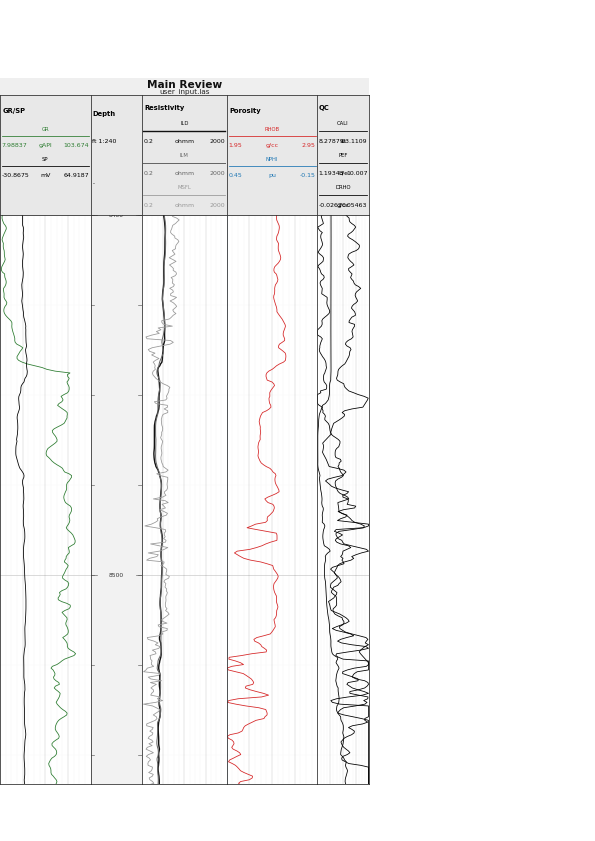

In [16]:
qc_result = await session.revise(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    feedback=dedent(
        """
        Revise the existing draft.

        - Add one narrow QC track after the porosity track.
        - Bind supporting curves such as CALI, PEF, and DRHO only when they are available.
        - Keep the track readable and lighter-weight than the main interpretation tracks.
        """
    ).strip(),
    max_rounds=REVISION_MAX_ROUNDS,
)

show_agent_result("QC track", qc_result)

## 8. Render The Final PDF

Once the section preview looks right, render the full draft through the public agent session helper so the notebook still uses the MCP-backed path.


In [17]:
render_result = await session.render_logfile_to_file(
    logfile_path=repo_relative(DRAFT_LOGFILE),
    output_path=repo_relative(FINAL_PDF),
    overwrite=True,
)

print("Rendered PDF:", render_result["output_path"])
print("Pages:", render_result["page_count"])

Rendered PDF: /home/user/projects/well_log_os/workspace/tutorials/agent_las_step_by_step/agent_open_hole_draft.pdf
Pages: 6
